In [205]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../src")
from utils import apply_theme_and_set_plot_params

COMM_AREAS_FE_DF_PATH = Path("../data/processed/community_areas_agg_fe_df.parquet")
fe_df = pd.read_parquet(COMM_AREAS_FE_DF_PATH)

In [206]:
# look at the dataframe
fe_df.head()

,COMMUNITY_AREA_NUMBER,COMMUNITY_AREA_NAME,PERCENT_OF_HOUSING_CROWDED,PERCENT_HOUSEHOLDS_BELOW_POVERTY,PERCENT_AGED_16__UNEMPLOYED,PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA,PERCENT_AGED_UNDER_18_OR_OVER_64,PER_CAPITA_INCOME,HARDSHIP_INDEX,UniqueNetworkManagersCount,...,MeanEnvironmentScore,MeanInstructionScore,MeanStudentAttendance,TotalCrimes,UniqueCrimeCategories,ArrestsCount,SchoolQualityScore,CrimesPerIncome,CrimesPerCrimeCategory,ArrestsPerCrime
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0,2,...,43.250000,36.750000,93.050000,6.0,6.0,3.0,39.850000,0.000251,1.0,0.500000
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0,2,...,58.444444,56.555556,94.922222,7.0,5.0,2.0,60.448413,0.000304,1.4,0.285714
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0,2,...,59.000000,58.000000,94.542857,4.0,1.0,4.0,54.375000,0.000112,4.0,1.000000
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0,2,...,46.600000,44.600000,92.840000,3.0,3.0,1.0,53.350000,0.000080,1.0,0.333333
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0,2,...,65.500000,51.166667,95.542857,4.0,4.0,2.0,71.375000,0.000070,1.0,0.500000


I drop a few features for the following reasons:

-`COMMUNITY_AREA_NUMBER`, `COMMUNITY_AREA_NAME`: the first one is just an identifier, which doesn't add value to the model. Regarding the second one, it is categorical and can't be used in KMeans.

-`HARDSHIP_INDEX`: other socioeconomic variables already include all the information needed for the model. Hard ship index just summarizes all of them.

-`SchoolQualityScore`: it is another summary of other average scores.

-`CrimesPerIncome`, `CrimesPerCrimeCategory`, `ArrestsPerCrime`: these are all derived features and the variables used to derive those are already present.

In [207]:
# select the features
features = ['PERCENT_OF_HOUSING_CROWDED', 'PERCENT_HOUSEHOLDS_BELOW_POVERTY',
       'PERCENT_AGED_16__UNEMPLOYED',
       'PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA',
       'PERCENT_AGED_UNDER_18_OR_OVER_64', 'PER_CAPITA_INCOME',
       'UniqueNetworkManagersCount', 'MeanSafetyScore',
       'MeanFamilyInvolvementScore', 'MeanEnvironmentScore',
       'MeanInstructionScore', 'MeanStudentAttendance', 'TotalCrimes',
       'UniqueCrimeCategories', 'ArrestsCount']
X = fe_df[features]

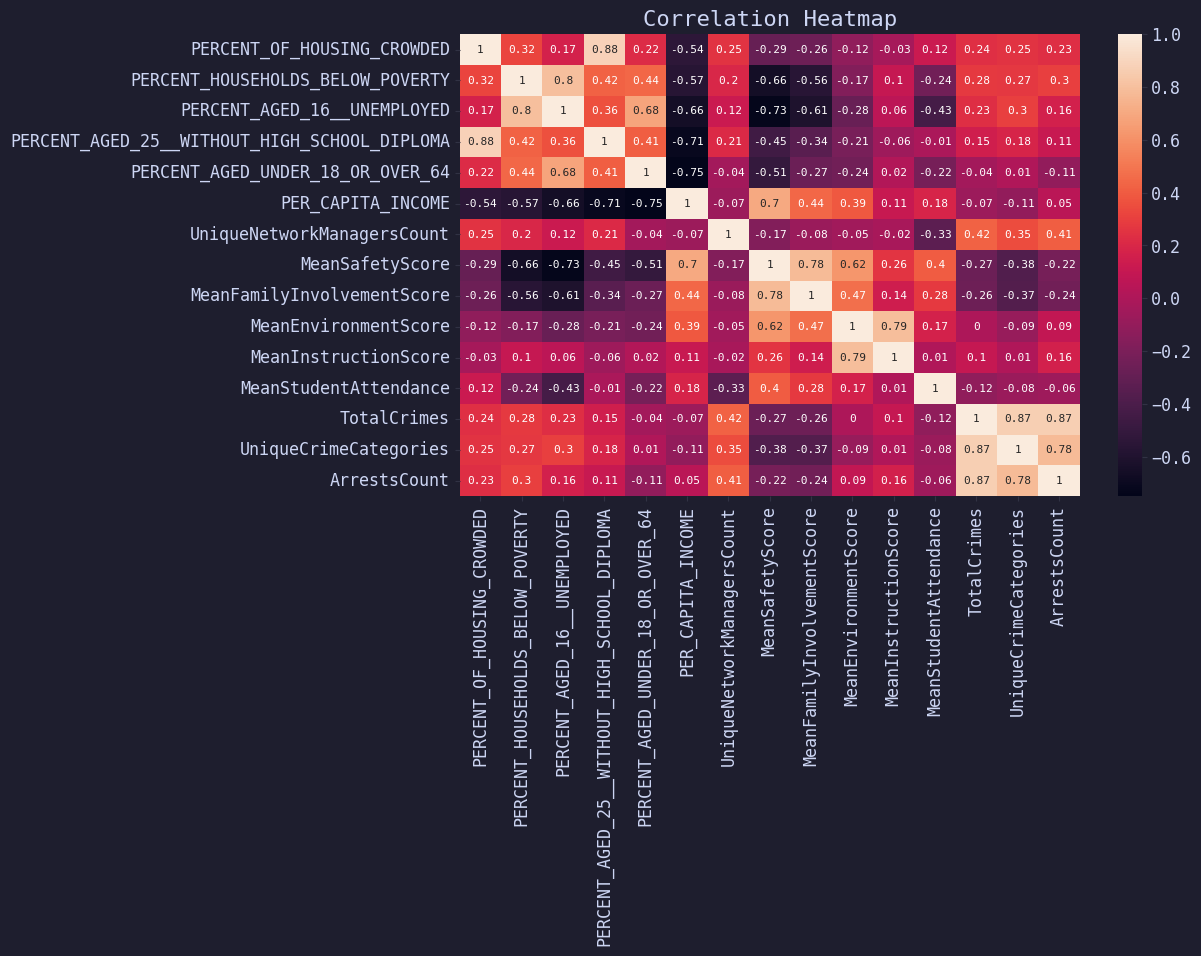

In [208]:
# create theme and set plot params first
apply_theme_and_set_plot_params()

# checking if there are other redundant variables
x_corrs = X.corr().round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(x_corrs, annot=True, annot_kws={"fontsize": 8})
plt.title("Correlation Heatmap")
plt.show()

In [209]:
# check skewness
X.skew().sort_values(ascending=False)

TotalCrimes                                     2.832699
PER_CAPITA_INCOME                               1.896166
ArrestsCount                                    1.744101
PERCENT_OF_HOUSING_CROWDED                      1.230923
MeanFamilyInvolvementScore                      0.858990
PERCENT_HOUSEHOLDS_BELOW_POVERTY                0.813058
PERCENT_AGED_16__UNEMPLOYED                     0.735354
MeanSafetyScore                                 0.725053
PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA    0.717884
UniqueCrimeCategories                           0.655785
UniqueNetworkManagersCount                      0.139250
MeanEnvironmentScore                           -0.289275
PERCENT_AGED_UNDER_18_OR_OVER_64               -0.997610
MeanStudentAttendance                          -1.051201
MeanInstructionScore                           -1.486155
dtype: float64

In [210]:
# log-transform skewed data
X = X.copy()

X["TotalCrimes"] = np.log1p(X["TotalCrimes"])
X["PER_CAPITA_INCOME"] = np.log1p(X["PER_CAPITA_INCOME"])
X["ArrestsCount"] = np.log1p(X["ArrestsCount"])

In [211]:
# scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

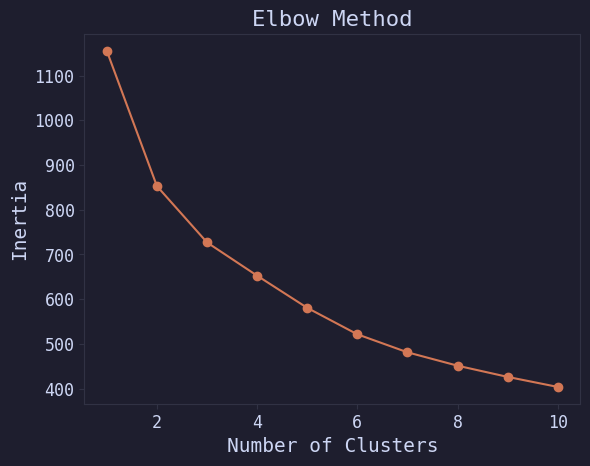

In [212]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot
plt.plot(range(1, 11), inertia, marker="o", color="#d37755")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

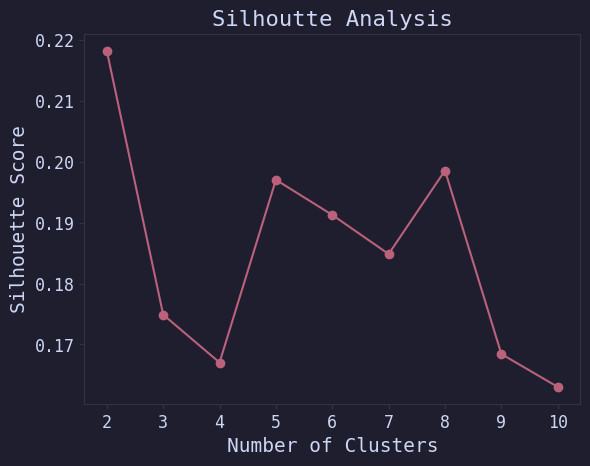

In [213]:
# silhouette score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    
# plot
plt.plot(range(2, 11), scores, color="#ba617c", marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhoutte Analysis")
plt.show()

In [214]:
# choose 2 for the best number of clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
fe_df["Cluster"] = kmeans.fit_predict(X_scaled)

# analyze clusters
cluster_summary = (fe_df.groupby("Cluster").agg(
    MeanPercHousingCrowded = ("PERCENT_OF_HOUSING_CROWDED", "mean"),
    MeanPercHouseholdsBelowPoverty = ("PERCENT_HOUSEHOLDS_BELOW_POVERTY", "mean"),
    MeanPercAged16Unemployed = ("PERCENT_AGED_16__UNEMPLOYED", "mean"),
    MeanPercAged25WithoutHighSchoolDiploma = ("PERCENT_AGED_25__WITHOUT_HIGH_SCHOOL_DIPLOMA", "mean"),
    MeanPercAgedUnder18OrOver64 = ("PERCENT_AGED_UNDER_18_OR_OVER_64", "mean"),
    MedianPerCapitaIncome = ("PER_CAPITA_INCOME", "median"),
    MeanUniqueNetworkManagersCount = ("UniqueNetworkManagersCount", "mean"),
    MeanSafetyScore = ("MeanSafetyScore", "mean"),
    MeanFamilyInvolvementScore = ("MeanFamilyInvolvementScore", "mean"),
    MeanEnvironmentScore = ("MeanEnvironmentScore", "mean"),
    MeanInstructionScore = ("MeanInstructionScore", "mean"),
    MeanStudentAttendance = ("MeanStudentAttendance", "mean"),
    MeanTotalCrimes = ("TotalCrimes", "mean"),
    MeanUniqueCrimeCategories = ("UniqueCrimeCategories", "mean"),
    MeanTotalArrests = ("ArrestsCount", "mean")
).round(2))

# look at the summary
cluster_summary.head()

,MeanPercHousingCrowded,MeanPercHouseholdsBelowPoverty,MeanPercAged16Unemployed,MeanPercAged25WithoutHighSchoolDiploma,MeanPercAgedUnder18OrOver64,MedianPerCapitaIncome,MeanUniqueNetworkManagersCount,MeanSafetyScore,MeanFamilyInvolvementScore,MeanEnvironmentScore,MeanInstructionScore,MeanStudentAttendance,MeanTotalCrimes,MeanUniqueCrimeCategories,MeanTotalArrests
Cluster,,,,,,,,,,,,,,,
0,6.40,30.04,20.99,26.64,39.58,15754.0,2.08,40.18,43.29,45.03,48.02,91.52,8.18,5.28,2.36
1,3.41,13.28,9.61,13.88,31.81,30397.5,1.66,64.12,60.34,50.16,47.41,93.60,4.50,3.05,1.34


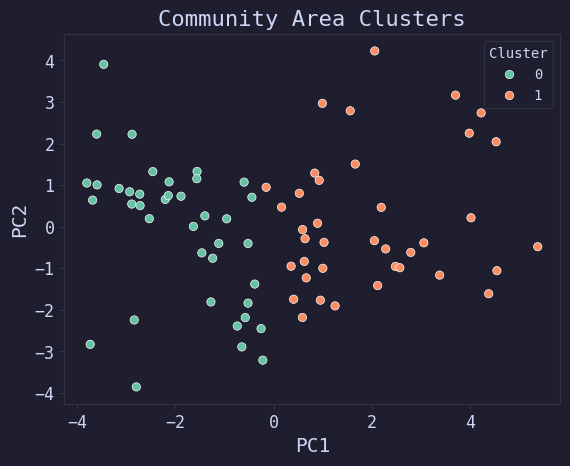

In [215]:
# visualize clusters with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# store results
fe_df["PC1"] = X_pca[:, 0]
fe_df["PC2"] = X_pca[:, 1]

# plot
sns.scatterplot(data=fe_df, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("Community Area Clusters")
plt.show()

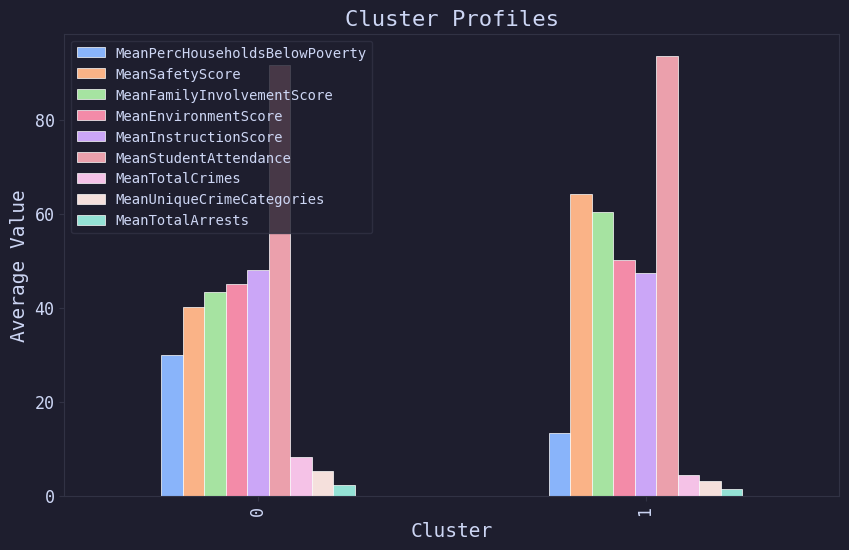

In [216]:
# profiling visualization
cluster_profile = fe_df.groupby("Cluster").agg(
    MeanPercHouseholdsBelowPoverty = ("PERCENT_HOUSEHOLDS_BELOW_POVERTY", "mean"),
    MeanSafetyScore = ("MeanSafetyScore", "mean"),
    MeanFamilyInvolvementScore = ("MeanFamilyInvolvementScore", "mean"),
    MeanEnvironmentScore = ("MeanEnvironmentScore", "mean"),
    MeanInstructionScore = ("MeanInstructionScore", "mean"),
    MeanStudentAttendance = ("MeanStudentAttendance", "mean"),
    MeanTotalCrimes = ("TotalCrimes", "mean"),
    MeanUniqueCrimeCategories = ("UniqueCrimeCategories", "mean"),
    MeanTotalArrests = ("ArrestsCount", "mean")
)

# plot it
cluster_profile.plot(kind="bar", figsize=(10, 6), edgecolor="white", linewidth=0.5)
plt.title("Cluster Profiles")
plt.ylabel("Average Value")
plt.show()

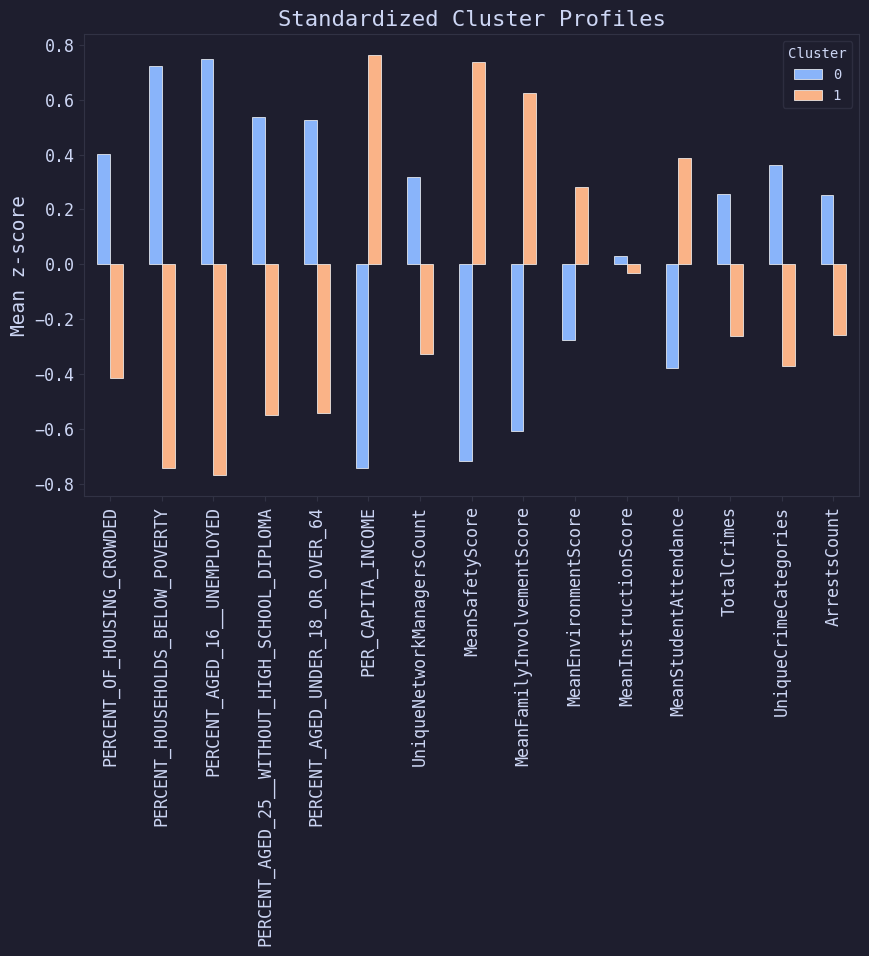

In [217]:
# standardize the data for the profile plot
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df["Cluster"] = fe_df["Cluster"]
cluster_profile = scaled_df.groupby("Cluster").mean()

cluster_profile.T.plot(kind="bar", figsize=(10, 6), edgecolor="white", linewidth=0.5)
plt.title("Standardized Cluster Profiles")
plt.ylabel("Mean z-score")
plt.show()

# Clustering Conclusions

A K-Means clustering model was trained to identify groups of similar community areas. The optimal number of clusters was determined using both the elbow method and silhouette analysis. While the elbow method suggested a solution between 2 and 3 clusters, the highest silhouette score (≈ 0.22) was obtained with 2 clusters, which was therefore selected as the final model.

The model identified two distinct community profiles:

• Cluster 0: Economically disadvantaged community areas characterized by higher unemployment, lower per capita income, higher poverty, more crowded housing, lower school safety and family involvement scores, and higher crime levels. 

• Cluster 1: More affluent community areas characterized by higher per capita income, lower poverty and unemployment, less crowded housing, higher school safety and family involvement scores, and lower crime levels. 

Although the silhouette score indicates only moderate cluster separation, the resulting clusters are interpretable and reveal meaningful socioeconomic differences between Chicago community areas.